# 1. Import / 경로 설정

In [2]:
# =========================================================
# 1. Import / Config
# =========================================================
from pathlib import Path
from collections import Counter, defaultdict
import warnings
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / "output" / "risk_detection_master"

TRAIN_MANIFEST_PATH = DATA_ROOT / "train_sample_manifest.csv"
TRAIN_PART_DIR = DATA_ROOT / "train_parts"

TARGET_COL = "target_estimation"
REASON_COL = "target_reason"
SAMPLE_KEY_COL = "sample_key"
TIMESTAMP_COL = "timestamp"
SEQ_NUM_COL = "seq_num"

NUMERIC_COLS = [
    "age",
    "em_temperature", "em_humidity", "em_illuminance", "em_activity_ir", "em_co2", "em_tvoc",
    "sm_heart_rate", "sm_breath_rate", "sm_spo2", "sm_skin_temperature",
    "sm_sleep_phase", "sm_sleep_score", "sm_walking_steps", "sm_stress_index",
    "sm_activity_intensity", "sm_caloric_expenditure",
    "er_button", "er_shout",
]

TEXT_COLS = [
    "ir_caption",
    "counseling_text",
    "counseling_memo",
    "counseling_information",
    "target_reason",
]

# 2. 유틸 함수

In [ ]:
# =========================================================
# 2. Helper
# =========================================================
def read_csv_safe(path: Path, **kwargs) -> pd.DataFrame:
    base_kwargs = {
        "engine": "python",       # 텍스트 깨짐/줄바꿈에 더 강함
        "on_bad_lines": "warn",   # 문제 행은 경고만 내고 넘김
    }
    base_kwargs.update(kwargs)

    try:
        return pd.read_csv(path, encoding="utf-8-sig", **base_kwargs)
    except Exception:
        return pd.read_csv(path, encoding="utf-8", **base_kwargs)

def get_part_files(part_dir: Path):
    return sorted(part_dir.glob("part_*.csv"))

def to_datetime_safe(series: pd.Series) -> pd.Series:
    return pd.to_datetime(series, errors="coerce")

def mode_or_nan(series: pd.Series):
    s = series.dropna()
    if len(s) == 0:
        return np.nan
    return s.mode().iloc[0]

def iqr_outlier_ratio(series: pd.Series) -> float:
    s = pd.to_numeric(series, errors="coerce").dropna()
    if len(s) < 5:
        return np.nan
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        return 0.0
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return float(((s < lower) | (s > upper)).mean())

def chunk_reader(files, usecols=None, chunksize=200_000):
    for f in files:
        print(f"[READ] {f.name}")
        for chunk in read_csv_safe(f, usecols=usecols, chunksize=chunksize):
            yield f, chunk

def sample_from_parts(files, n_parts=5, rows_per_part=5000, random_state=42):
    selected = files[:n_parts]
    dfs = []
    for f in selected:
        df = read_csv_safe(f)
        if len(df) > rows_per_part:
            df = df.sample(rows_per_part, random_state=random_state)
        dfs.append(df)
    if not dfs:
        return pd.DataFrame()
    return pd.concat(dfs, ignore_index=True)

# 3. manifest 확인

manifest shape: (824, 32)


,split,person_id,sex,seq,env_csv_path,bio_csv_path,ir_csv_path,emergency_csv_path,counsel_csv_path,meta_csv_path,label_json_path,ir_image_dir,sample_key,has_env_csv,has_bio_csv,has_ir_csv,has_emergency_csv,has_counsel_csv,has_meta_csv,has_label_json,env_csv_path_rows,env_csv_path_cols,bio_csv_path_rows,bio_csv_path_cols,ir_csv_path_rows,ir_csv_path_cols,emergency_csv_path_rows,emergency_csv_path_cols,counsel_csv_path_rows,counsel_csv_path_cols,meta_csv_path_rows,meta_csv_path_cols
0,train,A0003,F,10,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,A0003|F|010,True,True,True,True,True,True,True,6299,ID|Time|Temperature|Humidity|Illuminance|Activ...,6299.0,ID|Time|Heartrate|Breathrate|SPO2|Skin_Tempera...,6299.0,ID|Time|Image_IR|Caption,6299.0,ID|Time|Button|Voice,6299,device_scode|Time|information|counseling|MEMO,1,ID|Age|Gender|Region|DiseaseYN|ReceiptST|Envir...
1,train,A0004,F,10,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,A0004|F|010,True,True,True,True,True,True,True,5785,ID|Time|Temperature|Humidity|Illuminance|Activ...,5785.0,ID|Time|Heartrate|Breathrate|SPO2|Skin_Tempera...,5785.0,ID|Time|Image_IR|Caption,5785.0,ID|Time|Button|Voice,5785,device_scode|Time|information|counseling|MEMO,1,ID|Age|Gender|Region|DiseaseYN|ReceiptST|Envir...
2,train,A0005,M,10,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,A0005|M|010,True,True,True,True,True,True,True,3670,ID|Time|Temperature|Humidity|Illuminance|Activ...,3670.0,ID|Time|Heartrate|Breathrate|SPO2|Skin_Tempera...,3670.0,ID|Time|Image_IR|Caption,3670.0,ID|Time|Button|Voice,3670,device_scode|Time|information|counseling|MEMO,1,ID|Age|Gender|Region|DiseaseYN|ReceiptST|Envir...



[모달리티 존재 비율]


,true_ratio
has_env_csv,1.000000
has_meta_csv,1.000000
has_counsel_csv,1.000000
has_label_json,1.000000
has_bio_csv,0.029126
has_ir_csv,0.029126
has_emergency_csv,0.029126



[원천 파일 row 수 요약]


,count,mean,std,min,25%,50%,75%,max
env_csv_path_rows,824.0,52677.211165,18653.238357,18.0,39793.75,61010.0,68424.25,70415.0
bio_csv_path_rows,24.0,4191.791667,1859.160960,18.0,2445.25,4928.0,5660.75,6397.0
ir_csv_path_rows,24.0,4191.791667,1859.160960,18.0,2445.25,4928.0,5660.75,6397.0
emergency_csv_path_rows,24.0,4191.791667,1859.160960,18.0,2445.25,4928.0,5660.75,6397.0
counsel_csv_path_rows,824.0,52677.211165,18653.238357,18.0,39793.75,61010.0,68424.25,70415.0
meta_csv_path_rows,824.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0


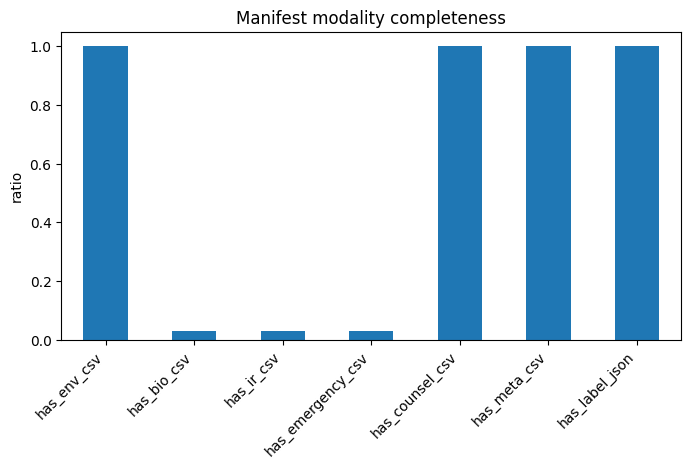

In [4]:
# =========================================================
# 3. Manifest EDA
# =========================================================
manifest = read_csv_safe(TRAIN_MANIFEST_PATH)

print("manifest shape:", manifest.shape)
display(manifest.head(3))

print("\n[모달리티 존재 비율]")
display(
    manifest[
        [
            "has_env_csv", "has_bio_csv", "has_ir_csv", "has_emergency_csv",
            "has_counsel_csv", "has_meta_csv", "has_label_json"
        ]
    ].mean().sort_values(ascending=False).rename("true_ratio").to_frame()
)

row_cols = [c for c in manifest.columns if c.endswith("_rows")]
print("\n[원천 파일 row 수 요약]")
display(manifest[row_cols].describe().T)

plt.figure(figsize=(8, 4))
manifest[
    [
        "has_env_csv", "has_bio_csv", "has_ir_csv", "has_emergency_csv",
        "has_counsel_csv", "has_meta_csv", "has_label_json"
    ]
].mean().plot(kind="bar")
plt.title("Manifest modality completeness")
plt.ylabel("ratio")
plt.xticks(rotation=45, ha="right")
plt.show()

# 4. part 파일 inventory 확인

num_parts: 42


,file,rows,size_mb
0,part_0000.csv,80227,151.81
1,part_0001.csv,1042782,850.46
2,part_0002.csv,1313068,1042.79
3,part_0003.csv,1330601,1056.84
4,part_0004.csv,1327829,1054.43
5,part_0005.csv,1317174,1046.19
6,part_0006.csv,1329432,1055.55
7,part_0007.csv,1326515,1052.98
8,part_0008.csv,1352309,1073.52
9,part_0009.csv,1304577,1035.64


,rows,size_mb
count,4.200000e+01,42.000000
mean,1.033477e+06,823.870000
std,3.387012e+05,263.525258
min,8.022700e+04,151.810000
25%,7.910488e+05,628.460000
50%,1.115484e+06,887.745000
75%,1.319474e+06,1048.417500
max,1.367716e+06,1089.600000


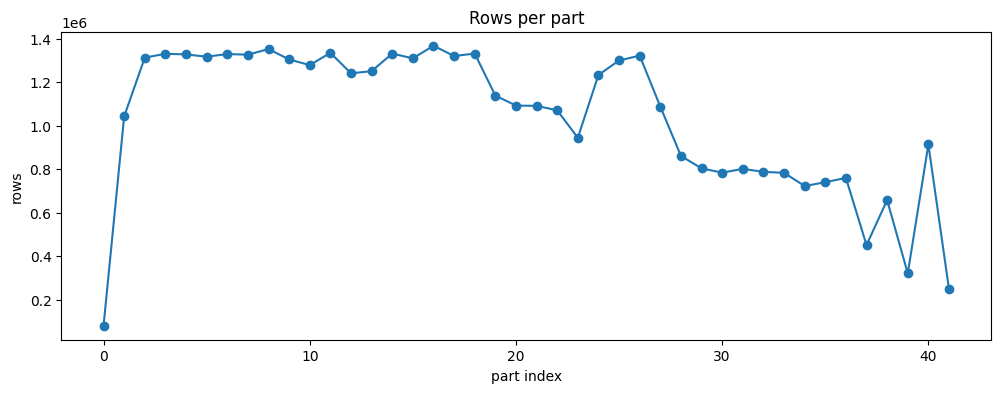

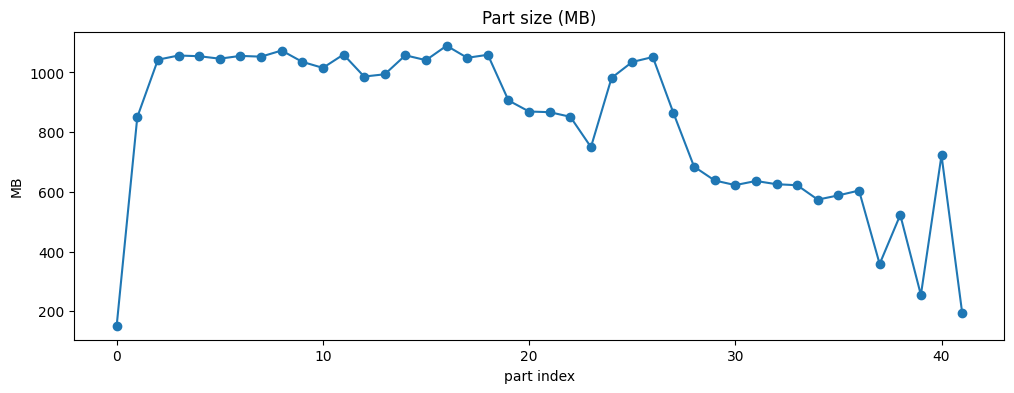

In [5]:
# =========================================================
# 4. Part inventory
# =========================================================
files = get_part_files(TRAIN_PART_DIR)
print("num_parts:", len(files))

rows = []
for f in files:
    with open(f, "r", encoding="utf-8-sig") as fp:
        line_count = sum(1 for _ in fp) - 1
    rows.append({
        "file": f.name,
        "rows": line_count,
        "size_mb": round(f.stat().st_size / 1024 / 1024, 2),
    })

inventory = pd.DataFrame(rows)
display(inventory.head(10))
display(inventory.describe())

plt.figure(figsize=(12, 4))
plt.plot(range(len(inventory)), inventory["rows"], marker="o")
plt.title("Rows per part")
plt.xlabel("part index")
plt.ylabel("rows")
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(range(len(inventory)), inventory["size_mb"], marker="o")
plt.title("Part size (MB)")
plt.xlabel("part index")
plt.ylabel("MB")
plt.show()

# 5. 샘플 데이터 로드

In [6]:
# =========================================================
# 5. Sample dataframe for fast EDA
# =========================================================
sample_df = sample_from_parts(files, n_parts=5, rows_per_part=5000, random_state=42)

print("sample_df shape:", sample_df.shape)
display(sample_df.head(3))
display(sample_df.dtypes.to_frame("dtype").head(20))

sample_df shape: (25000, 56)


,sample_id,sample_key,split,person_id,sex,seq,seq_num,timestamp,timestamp_raw,age,gender,region,disease_yn,receipt_st,environment,model_list,raw_unit_environmental,raw_unit_vitalring,env_csv_path,bio_csv_path,ir_csv_path,emergency_csv_path,counsel_csv_path,meta_csv_path,label_json_path,ir_image_dir,image_ir_name,image_ir_path,ir_timestamp,em_temperature,em_humidity,em_illuminance,em_activity_ir,em_co2,em_tvoc,em_label,sm_heart_rate,sm_breath_rate,sm_spo2,sm_skin_temperature,sm_sleep_phase,sm_sleep_score,sm_walking_steps,sm_stress_index,sm_activity_intensity,sm_caloric_expenditure,sm_label,ir_caption,er_button,er_shout,er_label,counseling_text,counseling_memo,counseling_information,target_estimation,target_reason
0,train_A0026_F_1_1001797,A0026|F|001,train,A0026,F,1,1001797,2024-10-28 13:10:00,2024-10-28T13:10,80,F,서울특별시,Y,Y,주택형,"['SME20SD', '바이탈링', 'MVPC10']","°C, RH, CdS%, au, ppm, ppb","bpm, br/min, %, °C, level, %, steps/10min, au,...",C:\Users\codeit44\Desktop\side_project\1.데이터\T...,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,IR_A0026_20241028_1310.png,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,2024-10-28 13:10:00,26.6,43.0,49.0,0,421.0,33.0,외출,70.0,15.0,99.0,0.0,9.0,0.0,0.0,0.0,0.0,0.0,일상,객체가 없음,0.0,0.0,일상,특이사항 없음.,특이사항 없음.,"취침 습관은, 12~4시, 중간에 잠을 많이 깨고 낮잠을 조금 자기도 함, 하루 2...",외출,특이사항 없음으로 일상 상황으로 판단
1,train_A0015_M_5_1002715,A0015|M|005,train,A0015,M,5,1002715,2024-11-03 00:20:00,2024-11-03T00:20,80,M,광주광역시,Y,Y,주택형,"['SME20SD', '바이탈링', 'MVPC10']","°C, RH, CdS%, au, ppm, ppb","bpm, br/min, %, °C, level, %, steps/10min, au,...",C:\Users\codeit44\Desktop\side_project\1.데이터\T...,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,IR_A0015_20241103_0020.png,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,2024-11-03 00:20:00,23.4,56.0,0.0,0,418.0,31.0,수면,52.0,16.0,97.0,-1.0,1.0,14.0,0.0,0.0,0.0,0.0,일상,객체가 없음,0.0,0.0,일상,특이사항 없음.,특이사항 없음.,"취침 습관은, 10:30~5시 정도 수면, 새벽에 화장실 자주 감, 일주일에 한두번...",주의,분당 심박 기준으로 주의 상황으로 판단
2,train_A0014_M_5_1000226,A0014|M|005,train,A0014,M,5,1000226,2024-11-09 13:40:00,2024-11-09T13:40,60,M,광주광역시,Y,Y,아파트형,"['SME20SD', '바이탈링', 'MVPC10']","°C, RH, CdS%, au, ppm, ppb","bpm, br/min, %, °C, level, %, steps/10min, au,...",C:\Users\codeit44\Desktop\side_project\1.데이터\T...,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,IR_A0014_20241109_1340.png,C:\Users\codeit44\Desktop\side_project\1.데이터\T...,2024-11-09 13:40:00,24.8,58.0,47.0,0,414.0,29.0,기타,58.0,19.0,96.0,0.0,9.0,0.0,37.0,0.0,91.0,13.0,일상,"객체가 1명 있고, 누워있음.",0.0,0.0,일상,특이사항 없음.,특이사항 없음.,"취침 습관은, 12~5시 정도 수면, 화장실 자주 들림, 집에서 2번 식사, 점심 ...",기타,특이사항 없음으로 일상 상황으로 판단


,dtype
sample_id,str
sample_key,str
split,str
person_id,str
sex,str
seq,int64
seq_num,int64
timestamp,str
timestamp_raw,str
age,int64


# 6. 전체 스캔 기반 핵심 통계

In [7]:
# =========================================================
# 6. Global scan (memory efficient)
# =========================================================
total_rows = 0
missing_counter = Counter()
target_counter = Counter()
reason_counter = Counter()
unique_samples = set()

usecols = list(set([
    SAMPLE_KEY_COL, TARGET_COL, REASON_COL, "sample_id", "image_ir_name", "image_ir_path"
] + NUMERIC_COLS + TEXT_COLS))

for _, chunk in chunk_reader(files, usecols=usecols, chunksize=200_000):
    total_rows += len(chunk)

    if SAMPLE_KEY_COL in chunk.columns:
        unique_samples.update(chunk[SAMPLE_KEY_COL].dropna().astype(str).unique().tolist())

    for col in chunk.columns:
        missing_counter[col] += int(chunk[col].isna().sum())

    if TARGET_COL in chunk.columns:
        target_counter.update(chunk[TARGET_COL].fillna("NaN").astype(str).value_counts().to_dict())

    if REASON_COL in chunk.columns:
        reason_counter.update(chunk[REASON_COL].fillna("NaN").astype(str).value_counts().head(200).to_dict())

print("total_rows:", total_rows)
print("unique_sample_key:", len(unique_samples))

missing_df = pd.DataFrame([
    {"column": c, "missing_count": v, "missing_ratio": v / total_rows if total_rows else np.nan}
    for c, v in missing_counter.items()
]).sort_values("missing_ratio", ascending=False)

print("\n[결측치 비율 TOP 20]")
display(missing_df.head(20))

target_df = pd.DataFrame(target_counter.items(), columns=[TARGET_COL, "count"]).sort_values("count", ascending=False)
print("\n[target_estimation 분포]")
display(target_df)

reason_df = pd.DataFrame(reason_counter.items(), columns=[REASON_COL, "count"]).sort_values("count", ascending=False)
print("\n[target_reason 상위]")
display(reason_df.head(20))

IndexError: list index out of range

# 7. 타깃 불균형 확인

In [ ]:
# =========================================================
# 7. Target imbalance
# =========================================================
plt.figure(figsize=(10, 5))
plt.bar(target_df[TARGET_COL].astype(str), target_df["count"])
plt.title("target_estimation distribution (row-level)")
plt.xticks(rotation=45, ha="right")
plt.show()

row_non_normal_ratio = (
    target_df.loc[target_df[TARGET_COL].astype(str) != "일상", "count"].sum()
    / target_df["count"].sum()
)

print("row-level non-normal ratio:", round(float(row_non_normal_ratio), 4))

# 8. sample 단위 길이 / 라벨 분포

In [ ]:
# =========================================================
# 8. Sample-level EDA
# =========================================================
partial_df = pd.concat([read_csv_safe(f) for f in files[:8]], ignore_index=True)
partial_df[TIMESTAMP_COL] = to_datetime_safe(partial_df[TIMESTAMP_COL])
partial_df["ir_timestamp"] = to_datetime_safe(partial_df["ir_timestamp"])

partial_df = partial_df.sort_values([SAMPLE_KEY_COL, TIMESTAMP_COL, SEQ_NUM_COL]).reset_index(drop=True)

sample_len = partial_df.groupby(SAMPLE_KEY_COL).size().rename("rows_per_sample").reset_index()
display(sample_len.describe())

plt.figure(figsize=(8, 5))
plt.hist(sample_len["rows_per_sample"], bins=40)
plt.title("rows per sample (partial)")
plt.xlabel("rows_per_sample")
plt.ylabel("count")
plt.show()

sample_target = partial_df.groupby(SAMPLE_KEY_COL)[TARGET_COL].agg(mode_or_nan).reset_index()
sample_target_vc = sample_target[TARGET_COL].fillna("NaN").astype(str).value_counts()

print("\n[sample-level target distribution]")
display(sample_target_vc.to_frame("count"))

plt.figure(figsize=(10, 5))
sample_target_vc.plot(kind="bar")
plt.title("target_estimation distribution (sample-level, partial)")
plt.xticks(rotation=45, ha="right")
plt.show()

# 9. 시간 흐름 점검

In [ ]:
# =========================================================
# 9. Time continuity / ordering
# =========================================================
partial_df["prev_timestamp"] = partial_df.groupby(SAMPLE_KEY_COL)[TIMESTAMP_COL].shift(1)
partial_df["gap_min"] = (partial_df[TIMESTAMP_COL] - partial_df["prev_timestamp"]).dt.total_seconds() / 60

display(partial_df["gap_min"].describe())

plt.figure(figsize=(8, 5))
plt.hist(partial_df["gap_min"].dropna(), bins=50)
plt.title("timestamp gap (minutes)")
plt.xlabel("gap_min")
plt.ylabel("count")
plt.show()

backward_rows = int((partial_df["gap_min"] < 0).fillna(False).sum())
zero_gap_rows = int((partial_df["gap_min"] == 0).fillna(False).sum())

print("timestamp backward rows:", backward_rows)
print("timestamp zero-gap rows:", zero_gap_rows)

# 10. 이미지 시간 매칭 확인

In [ ]:
# =========================================================
# 10. Image-time matching
# =========================================================
partial_df["image_time_diff_sec"] = (
    partial_df["ir_timestamp"] - partial_df[TIMESTAMP_COL]
).dt.total_seconds().abs()

display(partial_df["image_time_diff_sec"].describe())

match_ratio_60s = (partial_df["image_time_diff_sec"] <= 60).mean()
print("image-time match ratio within 60 sec:", round(float(match_ratio_60s), 4))

plt.figure(figsize=(8, 5))
plt.hist(partial_df["image_time_diff_sec"].dropna(), bins=50)
plt.title("image-time diff (sec)")
plt.xlabel("seconds")
plt.ylabel("count")
plt.show()

# 11. 수치형 센서 통계 + 이상치 비율

In [ ]:
# =========================================================
# 11. Numeric sensor statistics
# =========================================================
numeric_summary_rows = []

for col in NUMERIC_COLS:
    if col not in partial_df.columns:
        continue

    s = pd.to_numeric(partial_df[col], errors="coerce")
    numeric_summary_rows.append({
        "column": col,
        "count_non_null": int(s.notna().sum()),
        "mean": float(s.mean()) if s.notna().sum() else np.nan,
        "std": float(s.std()) if s.notna().sum() else np.nan,
        "min": float(s.min()) if s.notna().sum() else np.nan,
        "q25": float(s.quantile(0.25)) if s.notna().sum() else np.nan,
        "median": float(s.median()) if s.notna().sum() else np.nan,
        "q75": float(s.quantile(0.75)) if s.notna().sum() else np.nan,
        "max": float(s.max()) if s.notna().sum() else np.nan,
        "iqr_outlier_ratio": iqr_outlier_ratio(s),
    })

numeric_summary_df = pd.DataFrame(numeric_summary_rows).sort_values(
    "iqr_outlier_ratio", ascending=False
)

display(numeric_summary_df)

for col in ["em_co2", "em_tvoc", "sm_heart_rate", "sm_spo2", "sm_stress_index"]:
    if col in partial_df.columns:
        plt.figure(figsize=(8, 4))
        plt.hist(pd.to_numeric(partial_df[col], errors="coerce").dropna(), bins=50)
        plt.title(col)
        plt.show()

# 12. 응급 관련 컬럼 확인

In [ ]:
# =========================================================
# 12. Emergency-related columns
# =========================================================
for col in ["er_button", "er_shout", "er_label"]:
    if col in partial_df.columns:
        print(f"\n[{col}]")
        display(partial_df[col].fillna("NaN").astype(str).value_counts().head(20).to_frame("count"))

if "er_button" in partial_df.columns:
    s = pd.to_numeric(partial_df["er_button"], errors="coerce").fillna(0)
    print("er_button > 0 ratio:", round(float((s > 0).mean()), 4))

if "er_shout" in partial_df.columns:
    s = pd.to_numeric(partial_df["er_shout"], errors="coerce").fillna(0)
    print("er_shout > 0 ratio:", round(float((s > 0).mean()), 4))

# 13. 텍스트 컬럼 길이 / 내용 특성

In [ ]:
# =========================================================
# 13. Text columns
# =========================================================
text_len_rows = []

for col in TEXT_COLS:
    if col in partial_df.columns:
        lens = partial_df[col].fillna("").astype(str).map(len)
        text_len_rows.append({
            "column": col,
            "mean_len": lens.mean(),
            "median_len": lens.median(),
            "max_len": lens.max(),
            "empty_ratio": (lens == 0).mean(),
        })

text_len_df = pd.DataFrame(text_len_rows)
display(text_len_df)

for col in ["ir_caption", "counseling_text", "target_reason"]:
    if col in partial_df.columns:
        print(f"\n[{col} 예시]")
        display(partial_df[col].fillna("").astype(str).value_counts().head(10).to_frame("count"))

# 14. 정상 vs 비정상 비교

In [ ]:
# =========================================================
# 14. Normal vs Non-normal comparison
# =========================================================
partial_df["is_non_normal"] = partial_df[TARGET_COL].fillna("").astype(str) != "일상"

compare_rows = []
for col in NUMERIC_COLS:
    if col not in partial_df.columns:
        continue
    s = pd.to_numeric(partial_df[col], errors="coerce")
    normal_mean = s[partial_df["is_non_normal"] == False].mean()
    abnormal_mean = s[partial_df["is_non_normal"] == True].mean()

    compare_rows.append({
        "column": col,
        "normal_mean": normal_mean,
        "non_normal_mean": abnormal_mean,
        "diff": abnormal_mean - normal_mean if pd.notna(normal_mean) and pd.notna(abnormal_mean) else np.nan,
    })

compare_df = pd.DataFrame(compare_rows).sort_values("diff", key=lambda x: x.abs(), ascending=False)
display(compare_df)

# 15. 시간대별 비정상 비율

In [ ]:
# =========================================================
# 15. Non-normal ratio by hour
# =========================================================
partial_df["hour"] = partial_df[TIMESTAMP_COL].dt.hour
hour_ratio = partial_df.groupby("hour")["is_non_normal"].mean().reset_index()
hour_ratio.rename(columns={"is_non_normal": "non_normal_ratio"}, inplace=True)

display(hour_ratio)

plt.figure(figsize=(8, 4))
plt.plot(hour_ratio["hour"], hour_ratio["non_normal_ratio"], marker="o")
plt.title("non-normal ratio by hour")
plt.xlabel("hour")
plt.ylabel("ratio")
plt.show()